In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
bank = pd.read_csv(r"D:\Download\churn.csv")
bank.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


### 1️⃣ Overall Business Understanding
1.	What is the overall churn rate?
2.	What percentage of customers are active vs inactive?
3.	What is the average age, balance, and credit score of customers?

In [3]:
# Overall Churn Rate :
total_customer = bank.shape[0]
total_exited_customer = bank["Exited"].sum()
total_churn_rate = total_exited_customer*100/total_customer


print("Total customer:",total_customer)
print("Total exited customer:",total_exited_customer)
print("churn rate:", total_churn_rate)

Total customer: 10000
Total exited customer: 2037
churn rate: 20.37


In [4]:
# What percentage of customers are active vs inactive?
active_customer = bank.loc[bank["IsActiveMember"]==1]
inactive_customer = bank.loc[bank["IsActiveMember"]==0]

active_customer_pct = len(active_customer)*100/ total_customer
inactive_customer_pct = len(inactive_customer)*100/ total_customer

print("Percentage of active customer:", active_customer_pct)
print("Percentage of inactive customer:", inactive_customer_pct)

Percentage of active customer: 51.51
Percentage of inactive customer: 48.49


In [5]:
# What is the average age, balance, and credit score of customers?
avg_age = bank["Age"].mean()
avg_balance = bank["Balance"].mean()
avg_credit_score = bank["CreditScore"].mean()

print("Average Age:", avg_age)
print("Average Balance:", avg_balance)
print("Average credit score:", avg_credit_score)

Average Age: 38.9218
Average Balance: 76485.889288
Average credit score: 650.5288


### 2️⃣ Customer Segmentation Analysis

#### 📍 Geography-Based: 
1.	Which country has the highest churn rate?
2.	Which country has the highest average balance?
3.	Is churn concentrated in a specific region?

In [6]:
# Which country has the highest churn rate?
cust_by_country = bank.groupby("Geography")["CustomerId"].count().reset_index()
exit_cust_by_country = bank.groupby("Geography")["Exited"].sum().reset_index()

churn_by_geography = pd.merge(cust_by_country, exit_cust_by_country)
churn_by_geography["Churn Rate"] = churn_by_geography["Exited"]*100/ churn_by_geography["CustomerId"]

print(churn_by_geography)

  Geography  CustomerId  Exited  Churn Rate
0    France        5014     810   16.154767
1   Germany        2509     814   32.443204
2     Spain        2477     413   16.673395


In [7]:
# Which country has the highest average balance?
country_avg_balance = bank.groupby("Geography")["Balance"].mean().reset_index().sort_values(by="Balance", ascending= False)
country_avg_balance

,Geography,Balance
1,Germany,119730.116134
0,France,62092.636516
2,Spain,61818.147763


In [8]:
germany_cust = bank.loc[bank["Geography"]=="Germany"]
germany_active_pct = germany_cust["IsActiveMember"].sum()*100/ len(germany_cust)
print("Active member percentage of Germany is:",germany_active_pct)

Active member percentage of Germany is: 49.740932642487046


#### 👥 Gender-Based Questions
1.	Do females churn more than males?
2.	What is the average balance by gender?
3.	Is there a credit score difference between genders?

In [9]:
# Do females churn more than males?
female_cust= bank.loc[bank["Gender"]=="Female"]
female_cust_churn = female_cust["Exited"].sum()*100/len(female_cust)

male_cust= bank.loc[bank["Gender"]=="Male"]
male_cust_churn = female_cust["Exited"].sum()*100/len(male_cust)

print("churn rate of Females:", female_cust_churn)
print("churn rate of Males:", male_cust_churn)

churn rate of Females: 25.071538630860665
churn rate of Males: 20.87227414330218


In [10]:
# What is the average balance by gender?
avg_balance_gender = bank.groupby("Gender")["Balance"].mean()
avg_balance_gender

Gender
Female    75659.369139
Male      77173.974506
Name: Balance, dtype: float64

In [11]:
# Is there a credit score difference between genders?
bank.groupby("Gender")["CreditScore"].mean().reset_index()

,Gender,CreditScore
0,Female,650.831389
1,Male,650.276892


#### 🎂 Age-Based Questions
1.	What is the churn rate by age group?
2.	Do older customers churn more?
3.	What age range has the highest churn?

Create age buckets:
•	18–30
•	31–45
•	46–60
•	60+


In [12]:
# Create age buckets: • 18–30 • 31–45 • 46–60 • 60+
def age_category(age):
    if age >=18 and age <=30:
        return "18-30"
    elif age >=31 and age <=45:
        return "31-45"
    elif age >=46 and age<= 60:
        return "46-60"
    else:
        return "60+"
        
bank["Age Bucket"] = bank["Age"].apply(age_category)


In [13]:
# What is the churn rate by age group?
member_agebucket = bank["Age Bucket"].value_counts().reset_index()
active_agebucket = bank.groupby("Age Bucket")["Exited"].sum().reset_index()

churn_agebucket = pd.merge(member_agebucket, active_agebucket)
churn_agebucket["Churn"] = churn_agebucket["Exited"]*100 / churn_agebucket["count"]

In [14]:
churn_agebucket.sort_values(by="Churn", ascending= False)

,Age Bucket,count,Exited,Churn
2,46-60,1647,842,51.123254
3,60+,464,115,24.784483
0,31-45,5921,932,15.740584
1,18-30,1968,148,7.520325


#### 🏦 Product-Based Questions
1.	Does churn increase when customers have fewer products?
2.	What is churn rate for customers with 1 product vs 2 vs 3?
3.	Are multi-product customers more loyal?

In [15]:
# Does churn increase when customers have fewer products?
member_by_product = bank["NumOfProducts"].value_counts().reset_index()
exit_by_product = bank.groupby("NumOfProducts")["Exited"].sum().reset_index()

churn_by_product = pd.merge(member_by_product, exit_by_product)
churn_by_product["Churn"] = churn_by_product["Exited"]*100 / churn_by_product["count"]
churn_by_product

,NumOfProducts,count,Exited,Churn
0,1,5084,1409,27.714398
1,2,4590,348,7.581699
2,3,266,220,82.706767
3,4,60,60,100.000000


#### 💳 Credit Card & Activity Analysis
1.	Do inactive members churn more?
2.	Does having a credit card reduce churn?
3.  Are inactive + high balance customers at high risk?

In [16]:
# Do inactive members churn more?
inactive_customer_churn = inactive_customer["Exited"].sum()*100/len(inactive_customer)
active_customer_churn = active_customer["Exited"].sum()*100/len(active_customer)

print("inactive customer churn:", inactive_customer_churn)
print("active customer churn:", active_customer_churn)

inactive customer churn: 26.850897092183956
active customer churn: 14.269073966220152


In [17]:
# Does having a credit card reduce churn?
cust_with_crdc= bank.loc[bank["HasCrCard"]==1]
cust_without_crdc= bank.loc[bank["HasCrCard"]==0]

cust_with_crdc_churn = cust_with_crdc["Exited"].sum()*100/len(cust_with_crdc)
cust_without_crdc_churn = cust_without_crdc["Exited"].sum()*100/len(cust_without_crdc)

print("Churn rate of customers with credit card is:", cust_with_crdc_churn)
print("Churn rate of customers without credit card is:", cust_without_crdc_churn)

Churn rate of customers with credit card is: 20.184266477675408
Churn rate of customers without credit card is: 20.814940577249576


In [18]:
inactive_customer.shape

(4849, 14)

In [19]:
# 3.Are inactive + high balance customers at high risk?
bank["Balance Group"] = None
bank.loc[bank["Balance"]==0, "Balance Group"]= "Zero balance"

In [20]:
non_zero_mask = bank["Balance"]>0
bank.loc[non_zero_mask, "Balance Group"] = pd.qcut(
    bank.loc[non_zero_mask, "Balance"],
    q=3,
    labels = ["Low", "Medium", "high"]
)

In [21]:
balance_activity_churn = bank.groupby(["Balance Group","IsActiveMember"])["Exited"].mean()*100
balance_activity_churn = balance_activity_churn.reset_index().sort_values(by ="Exited", ascending= False)
balance_activity_churn

,Balance Group,IsActiveMember,Exited
2,Medium,0,35.282838
6,high,0,30.418251
0,Low,0,29.108911
3,Medium,1,20.202952
4,Zero balance,0,18.348624
7,high,1,16.078067
1,Low,1,14.579606
5,Zero balance,1,9.610251


### 3️⃣ Financial Risk Analysis:

#### 💰Balance-Based Questions:
1. Do customers with zero balance churn more?
2. Do high-balance customers churn?
3. What is churn rate by balance quartile?

In [22]:
# Do customers with zero balance churn more?
zero_balance_customer = bank.loc[bank["Balance"]==0]
zero_balance_customer_churn = zero_balance_customer["Exited"].sum()*100/ len(zero_balance_customer)

print("zero balance customer churn pct:", zero_balance_customer_churn)

zero balance customer churn pct: 13.823610727121924


In [23]:
churn_by_balance_group = bank.groupby("Balance Group")["Exited"].mean()*100
churn_by_balance_group.reset_index().sort_values(by="Exited", ascending= False)

,Balance Group,Exited
1,Medium,27.597555
3,high,23.167293
0,Low,21.475564
2,Zero balance,13.823611


In [24]:
bank["Balance Quartile"] = None
bank.loc[bank["Balance"]==0, "Balance Quartile"] = "Zero Balance"

In [25]:
# What is churn rate by balance quartile?
balance_quartile_mask = bank["Balance"]>0

bank.loc[balance_quartile_mask, "Balance Quartile"] = pd.qcut(
    bank.loc[balance_quartile_mask, "Balance"],
    q= 4,
    labels = ["Q1(Lowest)", "Q2", "Q3", "Q4(Highest)"],
    duplicates= "drop"
)

In [26]:
churn_by_quartile = bank.groupby("Balance Quartile")["Exited"].mean()*100
churn_by_quartile = churn_by_quartile.reset_index().sort_values(by="Exited", ascending= False)
churn_by_quartile

,Balance Quartile,Exited
1,Q2,27.380952
2,Q3,25.329154
3,Q4(Highest),22.994987
0,Q1(Lowest),20.614035
4,Zero Balance,13.823611


#### 💼 Salary-Based Questions
1.	Does estimated salary affect churn?
2.	Are high-salary customers leaving?
3.	What is churn rate by salary range?


In [27]:
# Does estimated salary affect churn?
bank["Salary Group"] = pd.qcut(
    bank["EstimatedSalary"],
    q= 3,
    labels= ["Low", "Medium", "High"]
)
churn_by_salary_group = bank.groupby("Salary Group")["Exited"].mean()*100
churn_by_salary_group = churn_by_salary_group.reset_index(). sort_values(by="Exited", ascending= False)
churn_by_salary_group

C:\Users\sourb\AppData\Local\Temp\ipykernel_19284\521304441.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_by_salary_group = bank.groupby("Salary Group")["Exited"].mean()*100


,Salary Group,Exited
2,High,21.212121
0,Low,20.132013
1,Medium,19.766047


###4️⃣Credit Risk Analysis
1. Do low credit score customers churn more?
2. Create credit score bands:
 Poor (<500)
 Fair (500–650)
 Good (650–750)
 Excellent (>750)
4. Which group has highest churn?


In [28]:
def credit_bucket(score):
    if score<500:
        return "Poor"
    elif score >=500 and score <=650:
        return "Fair"
    elif score >=650 and score <=750:
        return "Good"
    else:
        return "Excellent"
        
bank["Credit Score Group"] = bank["CreditScore"].apply(credit_bucket)

In [29]:
# Do low credit score customers churn more?
churn_by_credit_group = bank.groupby("Credit Score Group")["Exited"].mean()*100
churn_by_credit_group = churn_by_credit_group.reset_index().sort_values(by = "Exited",ascending = False)
churn_by_credit_group

,Credit Score Group,Exited
3,Poor,23.734177
1,Fair,21.068525
0,Excellent,19.586984
2,Good,19.249639


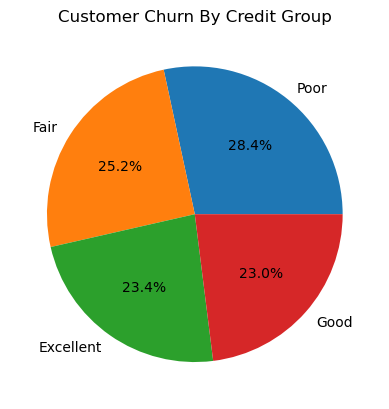

In [30]:
sizes = churn_by_credit_group["Exited"]
label = churn_by_credit_group["Credit Score Group"]

plt.pie(sizes,
       labels = label,
       autopct = '%1.1f%%')
plt.title("Customer Churn By Credit Group")

plt.show()

### 5️⃣ Tenure Analysis (Very Important)
1. Do new customers churn more?
2. Does churn decrease with tenure?
3. What is churn rate for customers with tenure < 3 years?


In [31]:
churn_by_tenure = bank.groupby("Tenure")["Exited"].mean()*100
churn_by_tenure = churn_by_tenure.reset_index().sort_values(by ="Exited", ascending=False)
churn_by_tenure

,Tenure,Exited
0,0,23.002421
1,1,22.415459
9,9,21.646341
3,3,21.110010
5,5,20.652174
10,10,20.612245
4,4,20.525784
6,6,20.268873
8,8,19.219512
2,2,19.179389


<function matplotlib.pyplot.show(close=None, block=None)>

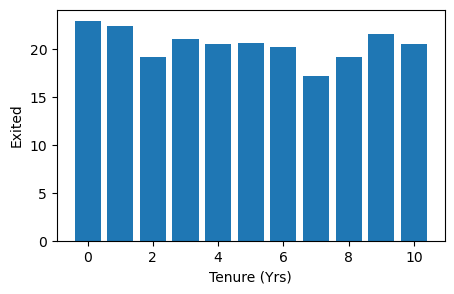

In [32]:
plt.figure(figsize= (5,3))
plt.bar(churn_by_tenure["Tenure"], churn_by_tenure["Exited"])
plt.xlabel("Tenure (Yrs)")
plt.ylabel("Exited")

plt.show

### 🧠 Multi-Factor Analysis:
1. Which segment has the highest churn?
a) Female + Germany + Age > 45
b) Inactive + 1 Product
c) High Balance + Low Tenure


In [33]:
# a) Female + Germany + Age > 45
bank_female_germany_45 = bank.loc[(bank["Gender"]=="Female") & (bank["Geography"]=="Germany") & (bank["Age"]>45)]
churn_bank_female_germany_45 = bank_female_germany_45["Exited"].sum()*100/len(bank_female_germany_45)
print("sample size:", len(bank_female_germany_45))
print("churn size:", bank_female_germany_45["Exited"].sum())
print("churn pct:", churn_bank_female_germany_45,"%")

sample size: 319
churn size: 211
churn pct: 66.14420062695925 %


In [34]:
# b) Inactive + 1 Product
bank_inactive_1product = bank.loc[(bank["IsActiveMember"]==0) & (bank["NumOfProducts"]==1)]
churn_bank_inactive_1product= bank_inactive_1product["Exited"].sum()*100 / len(bank_inactive_1product)
print("Sample size:", len(bank_inactive_1product))
print("churn size:", bank_inactive_1product["Exited"].sum())
print("churn rate:",churn_bank_inactive_1product,"%")

Sample size: 2521
churn size: 924
churn rate: 36.65212217374058 %
